In [46]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns



In [11]:
df = pd.read_csv("prestudy_final_results.csv")
df.columns.values[13] = 'group_number'
df.columns.values[9] = 'prolific_id'


In [13]:
def remove_ids(df, ids_to_remove):
    """
    Removes rows from the DataFrame where the 'prolific_id' is in the ids_to_remove list.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    ids_to_remove (list): List of prolific_id values to remove.

    Returns:
    pd.DataFrame: A new DataFrame with the specified ids removed.
    """
    return df[~df['prolific_id'].isin(ids_to_remove)]

df = remove_ids(df, ['60469275f75cd607f61fb973', '66187caf2a94f9051c85c431'])

In [16]:
mapping = {
    1: ('right', 'medium', 'LLM_simple'),
    2: ('right', 'medium', 'LLM_complex'),
    3: ('left', 'medium', 'LLM_simple'),
    4: ('left', 'medium', 'LLM_complex')
}

# Apply the mapping to create new columns
df[['article_orientation', 'article_bias_level', 'explanation_type']] = df['group_number'].map(mapping).apply(pd.Series)


In [18]:
df = df.rename(columns={
    "After reading the explanation, please tell us what you think about the following sentence: In my opinion, this article is biased.": "bias_t2",
    "Please tell us what you think about the following sentence: In my opinion, this article is biased.": "bias_t1",
    "Do you consider yourself to be liberal, conservative or somewhere in between?   [Political Orientation|Liberal|Conservative]": "Participant_Political_Lean",
    "The explanation was useful. [agree|disagree]": "Usefulness",
    "The explanation was complete. [agree|disagree]": "Completeness"
})

In [19]:
relevant_columns = [
    'article_orientation', 
    'article_bias_level',             
    'explanation_type',    
    'bias_t1',
    'bias_t2',
    'Participant_Political_Lean',
    'Usefulness',
    'Completeness'
]

df_relevant = df[relevant_columns].copy()

In [42]:
# Remove any zero-width spaces (or other invisible characters)
df_relevant['bias_t1'] = df_relevant['bias_t1'].str.replace(r'\u200b', '', regex=True)
df_relevant['bias_t2'] = df_relevant['bias_t2'].str.replace(r'\u200b', '', regex=True)

# Now you can safely strip any remaining whitespace and map the values
df_relevant['bias_t1'] = df_relevant['bias_t1'].str.strip()
df_relevant['bias_t2'] = df_relevant['bias_t2'].str.strip()
bias_scale = {
    "Strongly disagree": -3,
    "Disagree": -2,
    "Somewhat disagree": -1,
    "Somewhat agree": 1,
    "Agree": 2,
    "Strongly agree": 3
}

# Map responses in bias_t1 and bias_t2 to numeric values
df_relevant['bias_t1_num'] = df_relevant['bias_t1'].map(bias_scale)
df_relevant['bias_t2_num'] = df_relevant['bias_t2'].map(bias_scale)

# Calculate the change in perceived bias
df_relevant['biaschange'] = df_relevant['bias_t2_num'] - df_relevant['bias_t1_num']

In [45]:
df_relevant.to_excel('control.xlsx', index=False)

Mean bias change: 0.6
Median bias change: 1.0
Standard deviation: 1.9272482233188637
Count of positive changes: 30
Count of negative changes: 7
Count of zero changes: 13


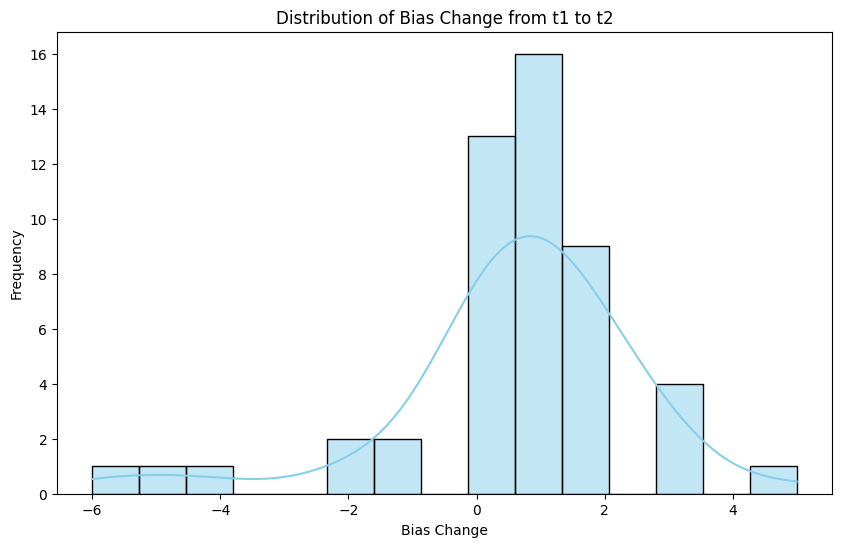

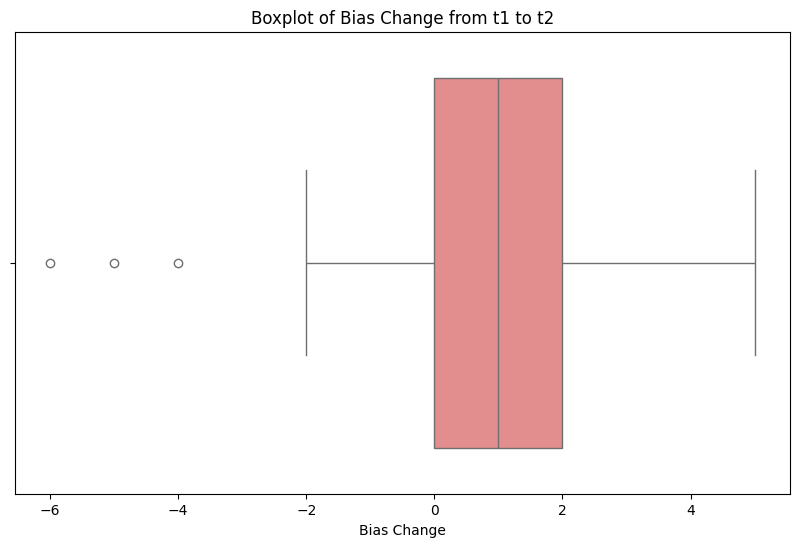

In [47]:
#General bias change analysis
mean_bias_change = df_relevant['biaschange'].mean()
median_bias_change = df_relevant['biaschange'].median()
std_bias_change = df_relevant['biaschange'].std()
count_positive = len(df_relevant[df_relevant['biaschange'] > 0])
count_negative = len(df_relevant[df_relevant['biaschange'] < 0])
count_zero = len(df_relevant[df_relevant['biaschange'] == 0])

print(f"Mean bias change: {mean_bias_change}")
print(f"Median bias change: {median_bias_change}")
print(f"Standard deviation: {std_bias_change}")
print(f"Count of positive changes: {count_positive}")
print(f"Count of negative changes: {count_negative}")
print(f"Count of zero changes: {count_zero}")

# 2. Visualization
plt.figure(figsize=(10, 6))

# Histogram of bias change
sns.histplot(df_relevant['biaschange'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Bias Change from t1 to t2')
plt.xlabel('Bias Change')
plt.ylabel('Frequency')

plt.show()

# Boxplot for visualizing the spread
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_relevant['biaschange'], color='lightcoral')
plt.title('Boxplot of Bias Change from t1 to t2')
plt.xlabel('Bias Change')

plt.show()

First Analysis: 

H1: Generation Technique
Prediction: LLM_complex leads to greater bias perception change (BiasChange) than the LLM_simple.

Analysis:
IVs: Explanation Type (explanation_technique: LLM_complex, LLM_simple)
DV: BiasChange
Test: ANOVA
Effects Tested:
Influence of explanation_technique on BiasChange

Interaction between explanation_technique \and article_bias
Followup tests (\if significant): Tukey’s HSD \or ttests comparing:
explanation_technique: LLM_simple vs. LLM_complex

In [48]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Make sure the categorical variables are treated as categories
df_relevant['explanation_type'] = pd.Categorical(df_relevant['explanation_type'])


# Check the unique values in your categorical variables
print(df_relevant['explanation_type'].unique())



['LLM_complex', 'LLM_simple']
Categories (2, object): ['LLM_complex', 'LLM_simple']


In [49]:
# Run ANOVA
model = ols('biaschange ~ C(explanation_type)', data=df_relevant).fit()
anova_results = anova_lm(model, typ=2)

# Print the ANOVA table
print(anova_results)

                         sum_sq    df        F    PR(>F)
C(explanation_type)    2.708535   1.0  0.72513  0.398695
Residual             179.291465  48.0      NaN       NaN


In [53]:
# Perform Tukey's HSD if ANOVA is significant
if anova_results['PR(>F)'][0] < 0.05:  # Check if ANOVA p-value is significant
    tukey = pairwise_tukeyhsd(endog=df_relevant['biaschange'],
                              groups=df_relevant['explanation_type'],
                              alpha=0.05)
    print(tukey.summary())


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2   meandiff p-adj   lower  upper  reject
------------------------------------------------------------
LLM_complex LLM_simple   -0.467 0.3987 -1.5696 0.6356  False
------------------------------------------------------------


In [51]:
mean_bias_change = df_relevant.groupby('explanation_type')['biaschange'].mean()
print(mean_bias_change)

explanation_type
LLM_complex    0.814815
LLM_simple     0.347826
Name: biaschange, dtype: float64


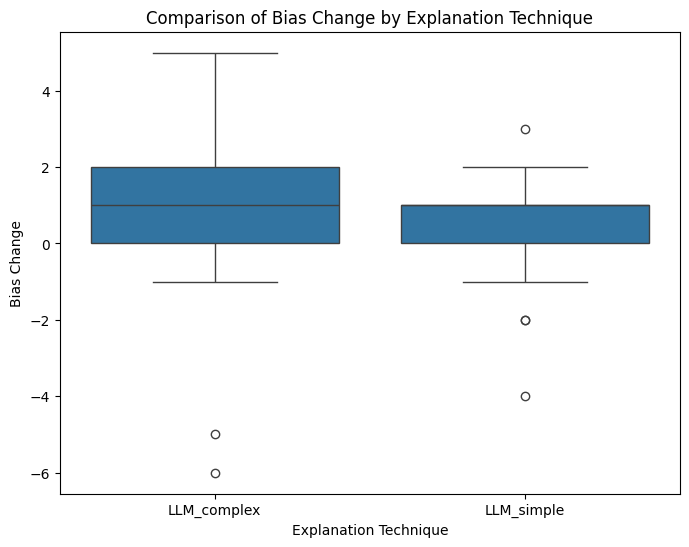

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot or violin plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='explanation_type', y='biaschange', data=df_relevant)
plt.title('Comparison of Bias Change by Explanation Technique')
plt.xlabel('Explanation Technique')
plt.ylabel('Bias Change')
plt.show()
